In [72]:
# Data loading and visual set-up

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
# Visual style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [75]:
df = pd.read_csv('ncr_ride_bookings.csv')
print("Initial DataFrame Information:")
df.info()
print("\nFirst 5 rows:")
print(df.head())

Initial DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason f

In [76]:
# Standardize column names

In [77]:
# Clean up column names
df.columns = df.columns.str.replace(' ', '_').str.replace('[^A-Za-z0-9_]+', '', regex=True)

# Correct specific column names found from AT2 file ('Cancelled_Rides_by_Customer' to 'Cancelled_by_Customer')
df.rename(columns={
    'Cancelled_Rides_by_Customer': 'Cancelled_by_Customer',
    'Cancelled_Rides_by_Driver': 'Cancelled_by_Driver',
    'Booking_Status': 'Ride_Status'
}, inplace=True)
print("\nCleaned Columns:")
print(df.columns)


Cleaned Columns:
Index(['Date', 'Time', 'Booking_ID', 'Ride_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'Avg_VTAT',
       'Avg_CTAT', 'Cancelled_by_Customer',
       'Reason_for_cancelling_by_Customer', 'Cancelled_by_Driver',
       'Driver_Cancellation_Reason', 'Incomplete_Rides',
       'Incomplete_Rides_Reason', 'Booking_Value', 'Ride_Distance',
       'Driver_Ratings', 'Customer_Rating', 'Payment_Method'],
      dtype='object')


In [78]:
# Date and time conversion (formatting)

In [79]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create a full "timestamp" column
df['Timestamp'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])

# Get useful time features
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Hour_of_Day'] = df['Time'].str.split(':').str[0].astype(int)

print("\nDate/Time conversion check:")
print(df[['Date', 'Time', 'Timestamp', 'Day_of_Week', 'Hour_of_Day']].head())


Date/Time conversion check:
        Date      Time           Timestamp Day_of_Week  Hour_of_Day
0 2024-03-23  12:29:38 2024-03-23 12:29:38    Saturday           12
1 2024-11-29  18:01:39 2024-11-29 18:01:39      Friday           18
2 2024-08-23  08:56:10 2024-08-23 08:56:10      Friday            8
3 2024-10-21  17:17:25 2024-10-21 17:17:25      Monday           17
4 2024-09-16  22:08:00 2024-09-16 22:08:00      Monday           22


In [80]:
# Handling missing values
# My previous report mentioned a substantial number of missing values. The columns with missing values fall into a few groups:
# 1. Status/Cancellation Info (Cancelled_by_Customer, Cancelled_by_Driver, etc.): These are often NaN if the ride was completed or no driver found. We can impute them to 0 (for count columns) or 'None' (for reason columns) for non-cancelled/non-incomplete rides.
# 2. Numerical KPIs (Avg_VTAT, Avg_CTAT, Booking_Value, Ride_Distance, Driver_Ratings, Customer_Rating): These are missing for rides that were not completed (when 'No Driver Found', 'Incomplete', 'Cancelled').

# For cancellation/incomplete columns, impute based on Ride_Status.
# For numerical KPIs, we will not impute them as they are genuine missing values due to the ride not being completed or rated. We will filter the dataset to 'Completed' rides for analyses involving these metrics, ensuring accuracy.

In [81]:
# Impute cancellation/incomplete columns for non-cancellation/non-incomplete statuses
# Fill NaN in count columns with 0
for col in ['Cancelled_by_Customer', 'Cancelled_by_Driver', 'Incomplete_Rides']:
    df[col] = df[col].fillna(0)

# Fill NaN in reason columns with 'N/A'
for col in ['Reason_for_cancelling_by_Customer', 'Driver_Cancellation_Reason', 'Incomplete_Rides_Reason']:
    df[col] = df[col].fillna('N/A')

print("\nMissing values after initial imputation (counts of NaN):")
print(df.isnull().sum())


Missing values after initial imputation (counts of NaN):
Date                                     0
Time                                     0
Booking_ID                               0
Ride_Status                              0
Customer_ID                              0
Vehicle_Type                             0
Pickup_Location                          0
Drop_Location                            0
Avg_VTAT                             10500
Avg_CTAT                             48000
Cancelled_by_Customer                    0
Reason_for_cancelling_by_Customer        0
Cancelled_by_Driver                      0
Driver_Cancellation_Reason               0
Incomplete_Rides                         0
Incomplete_Rides_Reason                  0
Booking_Value                        48000
Ride_Distance                        48000
Driver_Ratings                       57000
Customer_Rating                      57000
Payment_Method                       48000
Timestamp                              

In [82]:
# Assessing duplicates
print(f"\nNumber of duplicate rows (based on all columns): {df.duplicated().sum()}")

# If duplicates are found:
df.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(df)}")


Number of duplicate rows (based on all columns): 0
Number of rows after dropping duplicates: 150000


In [83]:
# Outlier management for 'Booking_Value' and 'Ride_Distance' using IQR method (I supported myself with Google and AI to apply this method)
# This is a method to identify extreme values without removing all of them

df_completed = df[df['Ride_Status'] == 'Completed'].copy()

for col in ['Booking_Value', 'Ride_Distance']:
    Q1 = df_completed[col].quantile(0.25)
    Q3 = df_completed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers_count = df_completed[(df_completed[col] < lower_bound) | (df_completed[col] > upper_bound)].shape[0]
    print(f"\n{col} Outlier count (IQR method): {outliers_count}")

    # Method instead of removal to retain data volume
    df_completed[col] = np.where(df_completed[col] > upper_bound, upper_bound, df_completed[col])
    df_completed[col] = np.where(df_completed[col] < lower_bound, lower_bound, df_completed[col])

print("\nCompleted rides data after outlier capping/flooring.")
df_completed.describe()


Booking_Value Outlier count (IQR method): 3127

Ride_Distance Outlier count (IQR method): 0

Completed rides data after outlier capping/flooring.


,Date,Avg_VTAT,Avg_CTAT,Cancelled_by_Customer,Cancelled_by_Driver,Incomplete_Rides,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Timestamp,Hour_of_Day
count,93000,93000.000000,93000.000000,93000.0,93000.0,93000.0,93000.000000,93000.000000,93000.000000,93000.000000,93000,93000.000000
mean,2024-06-30 15:42:15.329032448,8.511878,30.034772,0.0,0.0,0.0,491.810565,26.000493,4.230992,4.404584,2024-07-01 06:14:01.753290240,14.030806
min,2024-01-01 00:00:00,2.000000,15.000000,0.0,0.0,0.0,50.000000,2.000000,3.000000,3.000000,2024-01-01 00:19:34,0.000000
25%,2024-03-31 00:00:00,5.300000,22.600000,0.0,0.0,0.0,234.000000,14.100000,4.100000,4.200000,2024-03-31 21:12:46.500000,10.000000
50%,2024-06-30 00:00:00,8.500000,30.000000,0.0,0.0,0.0,414.000000,26.020000,4.300000,4.500000,2024-06-30 19:44:34,15.000000
75%,2024-09-30 00:00:00,11.800000,37.500000,0.0,0.0,0.0,689.000000,37.942500,4.600000,4.800000,2024-09-30 18:47:31.750000128,18.000000
max,2024-12-30 00:00:00,15.000000,45.000000,0.0,0.0,0.0,1371.500000,50.000000,5.000000,5.000000,2024-12-30 23:21:12,23.000000
std,NaN,3.748138,8.650707,0.0,0.0,0.0,331.439286,13.824176,0.436871,0.437819,NaN,5.423166


In [84]:
# Data visualization and business questions

In [85]:
# Q1: Distribution of vehicle types
# Goal: Understand the vehicle types booked
# Visualization: Bar chart

/tmp/ipython-input-1401270279.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Vehicle_Type', data=df, order=df['Vehicle_Type'].value_counts().index, palette='viridis')


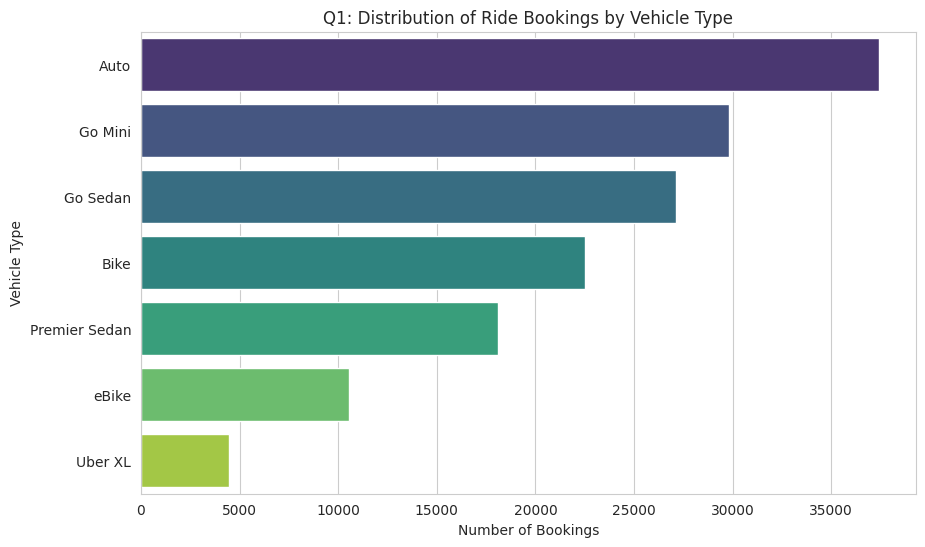

In [89]:
# Q1
plt.figure(figsize=(10, 6))
sns.countplot(y='Vehicle_Type', data=df, order=df['Vehicle_Type'].value_counts().index, palette='viridis')
plt.title('Q1: Distribution of Ride Bookings by Vehicle Type')
plt.xlabel('Number of Bookings')
plt.ylabel('Vehicle Type')
plt.show()

In [90]:
# Q2: Most frequent pick-up locations (for completed rides)
# Goal: Identify high-demand pick-up zones
# Visualization: Horizontal bar chart

Number of completed rides used for analysis: 93000


/tmp/ipython-input-3262471859.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_pickups.values, y=top_10_pickups.index, palette='magma')


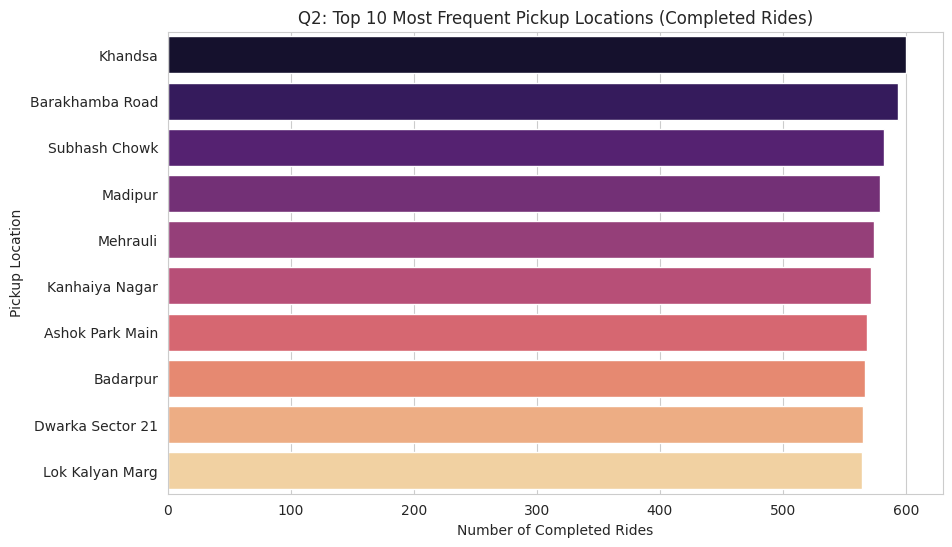

In [91]:
# This filter is necessary because pickup_location insights are strongest when based on successful transactions (not cancelled rides)
df_completed = df[df['Ride_Status'] == 'Completed'].copy()
print(f"Number of completed rides used for analysis: {len(df_completed)}")

#Q2
top_10_pickups = df_completed['Pickup_Location'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_pickups.values, y=top_10_pickups.index, palette='magma')
plt.title('Q2: Top 10 Most Frequent Pickup Locations (Completed Rides)')
plt.xlabel('Number of Completed Rides')
plt.ylabel('Pickup Location')
plt.show()

In [92]:
# Q3: How does the ride status distribution vary across the different vehicle types?
# Goal: Investigate service efficiency (completion, cancellation, no driver) by vehicle type
# Visualization: Stacked bar chart

<Figure size 1200x700 with 0 Axes>

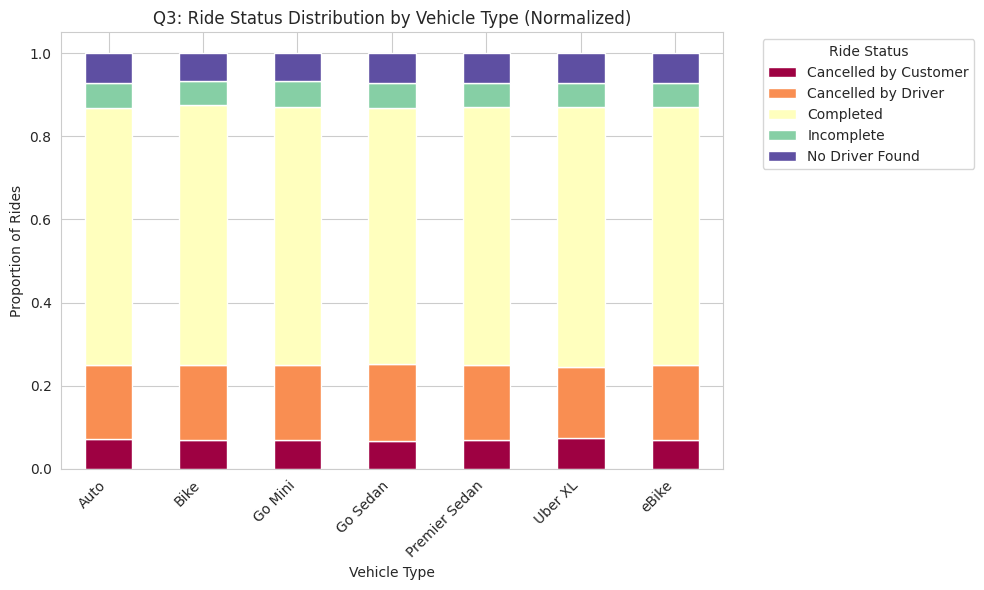

In [93]:
# Q3 (I supported this chart creation with AI)
status_by_vehicle = df.groupby(['Vehicle_Type', 'Ride_Status']).size().unstack(fill_value=0)
status_by_vehicle_norm = status_by_vehicle.apply(lambda x: x / x.sum(), axis=1) # Normalized

plt.figure(figsize=(12, 7))
status_by_vehicle_norm.plot(kind='bar', stacked=True, colormap='Spectral')
plt.title('Q3: Ride Status Distribution by Vehicle Type (Normalized)')
plt.xlabel('Vehicle Type')
plt.ylabel('Proportion of Rides')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ride Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [94]:
# Q4: What is the hourly trend of Booking Value and how does it compare across weekdays vs. weekends? (I supported this chart creation with AI)
# Goal: Identify peak revenue times and check for different pricing/demand patterns on weekdays vs. weekend
# Visualization: Line plot with grouping.

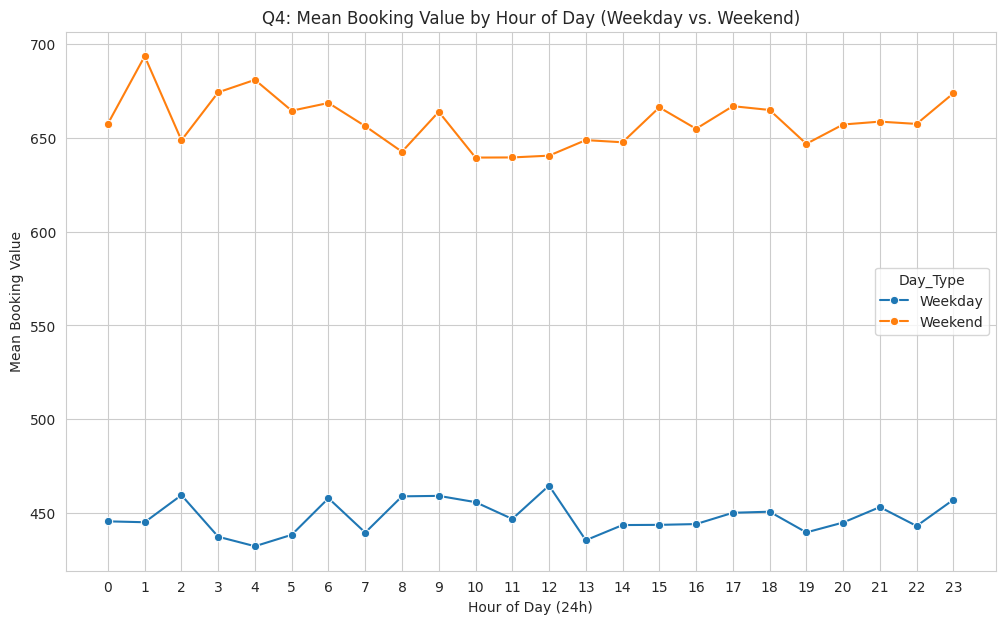

In [95]:
# Q4
# Create a 'Day_Type' column
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df_completed['Day_Type'] = df_completed['Day_of_Week'].apply(lambda x: 'Weekday' if x in weekday_names else 'Weekend')

# Calculate mean booking value by hour and day type
hourly_value = df_completed.groupby(['Hour_of_Day', 'Day_Type'])['Booking_Value'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=hourly_value, x='Hour_of_Day', y='Booking_Value', hue='Day_Type', marker='o')
plt.title('Q4: Mean Booking Value by Hour of Day (Weekday vs. Weekend)')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Mean Booking Value')
plt.xticks(range(0, 24))
plt.grid(True, axis='y')
plt.show()

In [96]:
# Q5: Is there a correlation between 'Ride Distance' and 'Customer Rating', and how does it vary by 'Payment Method'?
# Goal: Identify the correlation requirement by a categorical variable
# Visualization: Scatter plot with regression line and facet grids

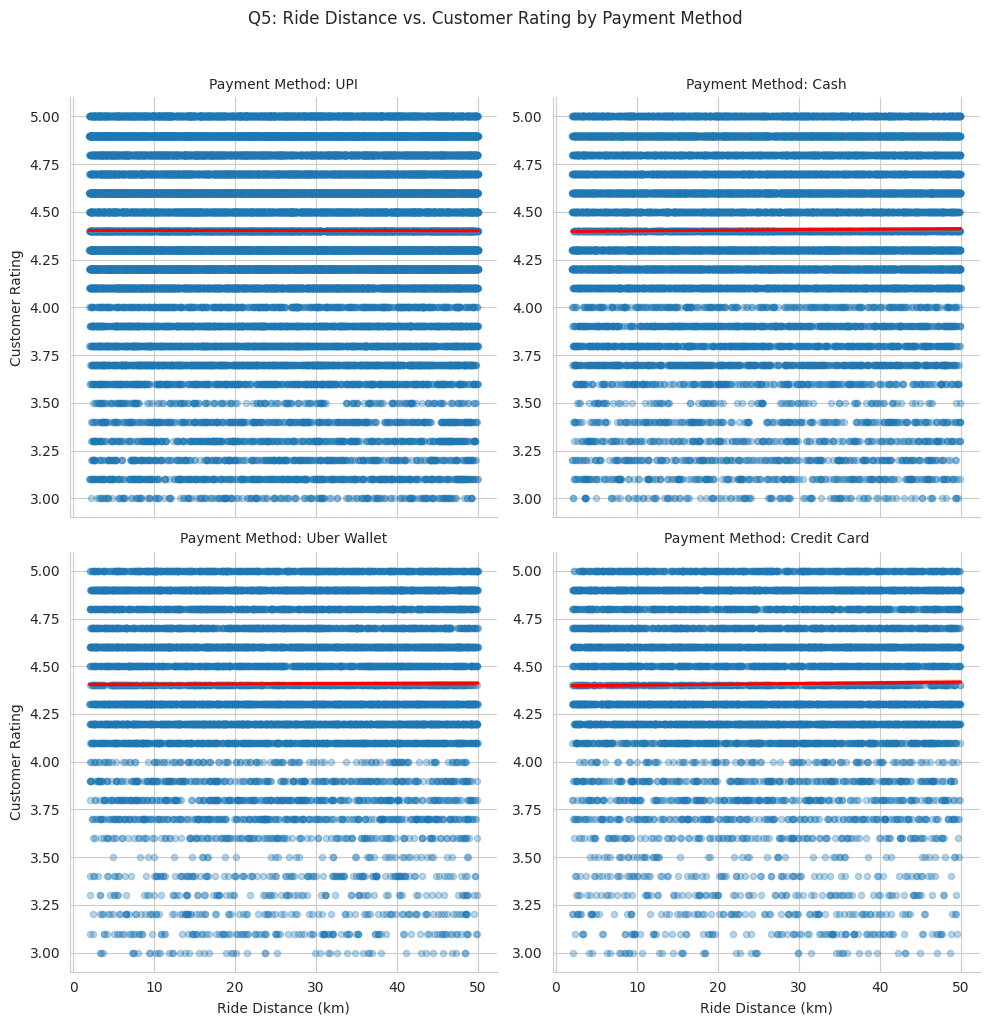

In [97]:
# Q5
# Use a subset of the most common payment methods for cleaner visualization
top_payment_methods = df_completed['Payment_Method'].value_counts().head(4).index
df_payment_subset = df_completed[df_completed['Payment_Method'].isin(top_payment_methods)]

# Create a FacetGrid of scatter plots
g = sns.FacetGrid(df_payment_subset, col="Payment_Method", col_wrap=2, height=5, sharey=False)
g.map(sns.regplot, "Ride_Distance", "Customer_Rating", scatter_kws={'alpha':0.3, 's':20}, line_kws={'color':'red'})

# Add titles and layout
g.set_axis_labels("Ride Distance (km)", "Customer Rating")
g.set_titles("Payment Method: {col_name}")
plt.suptitle('Q5: Ride Distance vs. Customer Rating by Payment Method', y=1.02)
plt.tight_layout()
plt.show()

In [98]:
# Q6: Which day of the week has the highest average ride distance, and how does this impact average booking value?
# Goal: Investigate demand patterns by day and link trip characteristics (in this case, distance) to financial performance (value)
# Visualization: two separate bar charts for clarity and simplicity)

/tmp/ipython-input-3474598389.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y='Ride_Distance', data=daily_metrics, palette='cividis')


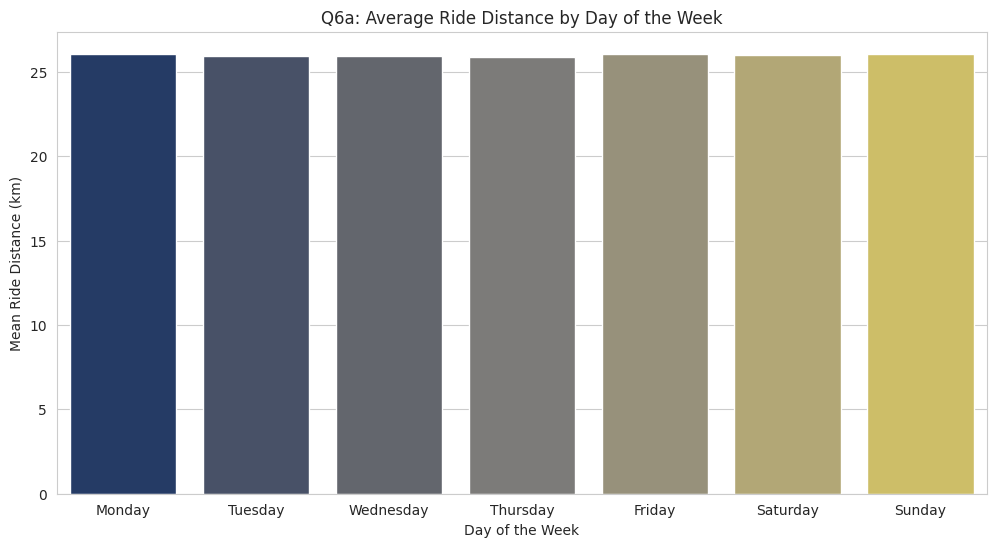

/tmp/ipython-input-3474598389.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_of_Week', y='Booking_Value', data=daily_metrics, palette='viridis')


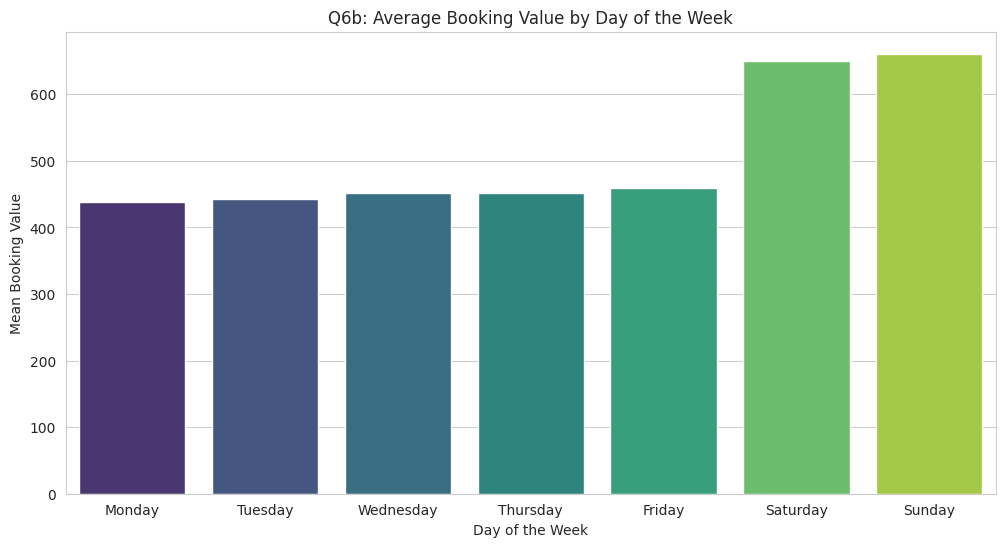

In [100]:
# Calculate the mean distance and mean booking value for each day of the week
daily_metrics = df_completed.groupby('Day_of_Week')[['Ride_Distance', 'Booking_Value']].mean().reset_index()

# Define the order of the days for proper plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_metrics['Day_of_Week'] = pd.Categorical(daily_metrics['Day_of_Week'], categories=day_order, ordered=True)
daily_metrics.sort_values('Day_of_Week', inplace=True)


# First bar chart: avge. ride distance by day
plt.figure(figsize=(12, 6))
sns.barplot(x='Day_of_Week', y='Ride_Distance', data=daily_metrics, palette='cividis')
plt.title('Q6a: Average Ride Distance by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Mean Ride Distance (km)')
plt.show()


# Second plot: averg. booking value by day
plt.figure(figsize=(12, 6))
sns.barplot(x='Day_of_Week', y='Booking_Value', data=daily_metrics, palette='viridis')
plt.title('Q6b: Average Booking Value by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Mean Booking Value')
plt.show()

In [101]:
# Final data (cleaned data)
print("\nFinal Cleaned (Completed Rides) DataFrame Information:")
df_completed.info()
print("\nDescriptive Statistics for Key Metrics:")
print(df_completed[['Booking_Value', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating']].describe())


Final Cleaned (Completed Rides) DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
Index: 93000 entries, 2 to 149999
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               93000 non-null  datetime64[ns]
 1   Time                               93000 non-null  object        
 2   Booking_ID                         93000 non-null  object        
 3   Ride_Status                        93000 non-null  object        
 4   Customer_ID                        93000 non-null  object        
 5   Vehicle_Type                       93000 non-null  object        
 6   Pickup_Location                    93000 non-null  object        
 7   Drop_Location                      93000 non-null  object        
 8   Avg_VTAT                           93000 non-null  float64       
 9   Avg_CTAT                           93000 non-null  fl